````{margin}
```{attributiongrey} Bronvermelding
:class: attribution

Deze oefening is gebaseerd op [deze oefening uit het online boek van het vak CTB2210 Constructiemechanica 3 op de Technische Universiteit Delft](https://oit.tudelft.nl/CTB2210/2025/ODE/lesoefeningen.html) {cite:p}`CTB2210_2025`.

```
````

# Opgave 3

Gegeven is de volgende constructie:

```{figure} ./opgave3_data/constructie.svg
:class: sticky-margin
:align: center
:source: https://github.com/Structural-Mechanics-CEG/mechanics-figures-source/tree/main/sympy_6
:number:
```

Vind de rotatie op in $x=0$.

:::::{exercise}
:nonumber: true

Maak de opdracht in [WebLab](https://weblab.tudelft.nl/ctb1310/2025-2026/assignment/166955). Heb je nog geen toegang? Schrijf je dan eerst [hier](https://weblab.tudelft.nl/ctb1310/2025-2026/enroll) in voor dit vak op WebLab. 

Je kan je antwoord op de vragen in de volgende opgaves invoeren. Maar om je code te checken klik je op 'Check' in WebLab.

:::::

::::{question} Opgave
:type: short-answer
:variant: blocks
:admonition:
:class: exercise
:nocaption:

Wat is het rotatie in $\rm{A} $ in $\rm{rad}$?
---
M[0.064]
---

::::

::::{admonition-start} Uitwerking
:class: solution, dropdown
::::

In [1]:
import sympy as sym
sym.init_printing(use_latex='mathjax')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display, Math

%config InlineBackend.figure_formats = ['svg']

def display(*objs):
    for obj in objs:
        if isinstance(obj, dict):
            lines = [f"{sym.latex(k)} &= {sym.latex(obj[k])}" for k in sorted(obj, key=lambda s: str(s))]
            ipy_display(Math(r"\begin{aligned}" + r"\\ ".join(lines) + r"\end{aligned}"))
        else:
            ipy_display(obj)

def plot(w_list, x_range_list,ylabel):
    fig = plt.figure(facecolor='none')
    for i, w in enumerate(w_list):
        # check if x is the only symbol in the expression
        if len(w.free_symbols) > 1:
            raise ValueError('The expression must be a function of x only.')
        
        w_numpy = sym.lambdify(x, w)
        x_vals = np.linspace(x_range_list[i][0], x_range_list[i][1], 100)
        
        # if the expression is a constant, we need to make sure that it is broadcasted correctly
        if isinstance(w_numpy(x_vals),float) or isinstance(w_numpy(x_vals),int):
            w_numpy = np.vectorize(w_numpy)
        plt.plot(x_vals,w_numpy(x_vals))
        plt.xlabel('$x$')
        plt.ylabel(ylabel)
    ax = plt.gca()
    ax.set_facecolor('none')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.invert_yaxis()

In [2]:
import sympy as sym

In [3]:
sym.var('x')
sym.var('C1, C2, C3, C4');

In [6]:
q1 = x * -12

In [7]:
V1 = sym.integrate(-q1,x)+C1
M1 = sym.integrate(V1,x)+C2
kappa1 = M1 / 6400
phi1 = sym.integrate(kappa1,x)+C3
w1 = sym.integrate(-phi1,x)+C4

In [8]:
Eq1  = sym.Eq(  w1.subs(x, 0), 0)
Eq2  = sym.Eq(  M1.subs(x, 0), 0)
Eq3  = sym.Eq(  w1.subs(x, 8), 0)
Eq4  = sym.Eq(phi1.subs(x, 8), 0)

In [9]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4), (C1, C2, C3, C4))
display(sol)

<IPython.core.display.Math object>

In [ ]:
w1_oplossing = w1.subs(sol)
phi1_oplossing = phi1.subs(sol)

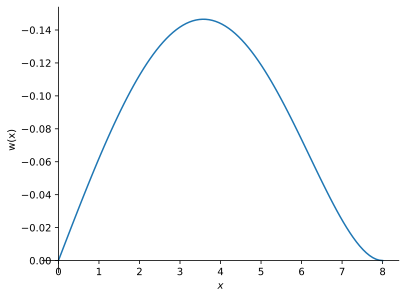

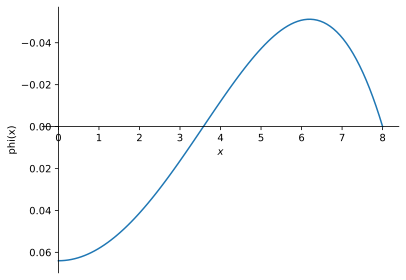

In [14]:
plot([w1_oplossing], [(0, 8)], 'w(x)')
plot([phi1_oplossing], [(0, 8)], 'phi(x)')

In [ ]:
phi_0 = phi1_oplossing.subs(x, 0) # rad
display(phi_0)
display(phi_0.evalf())

8/125

0.0640000000000000

::::{admonition-end}
::::